<a href="https://colab.research.google.com/github/TejashwiniByrappa/Tejashwini-landing-page/blob/main/bank.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (45211, 19)
Target column detected: 'response'


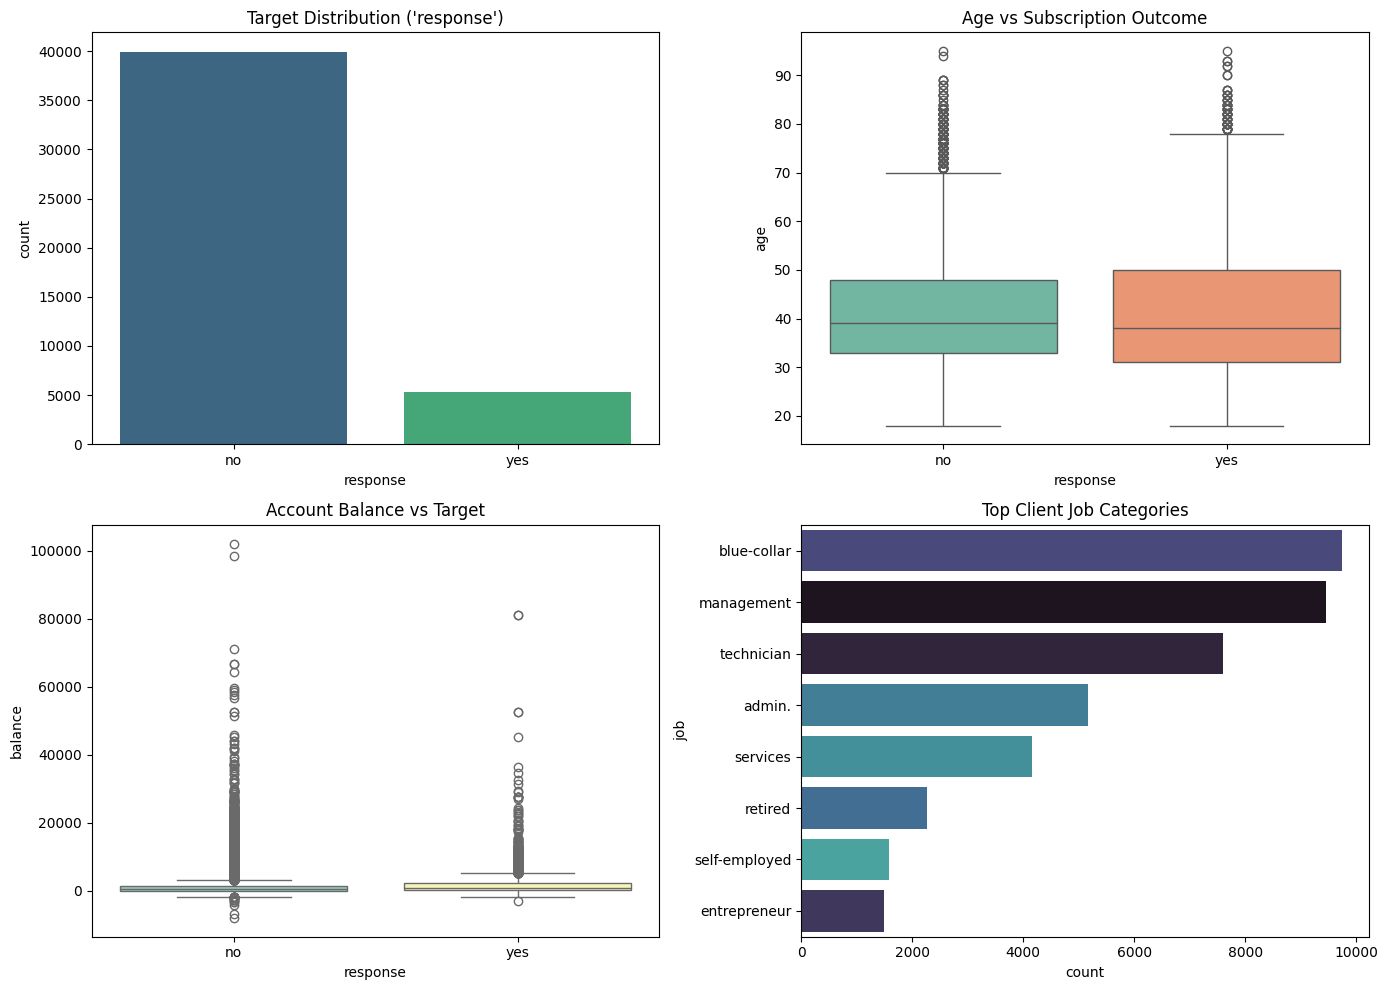

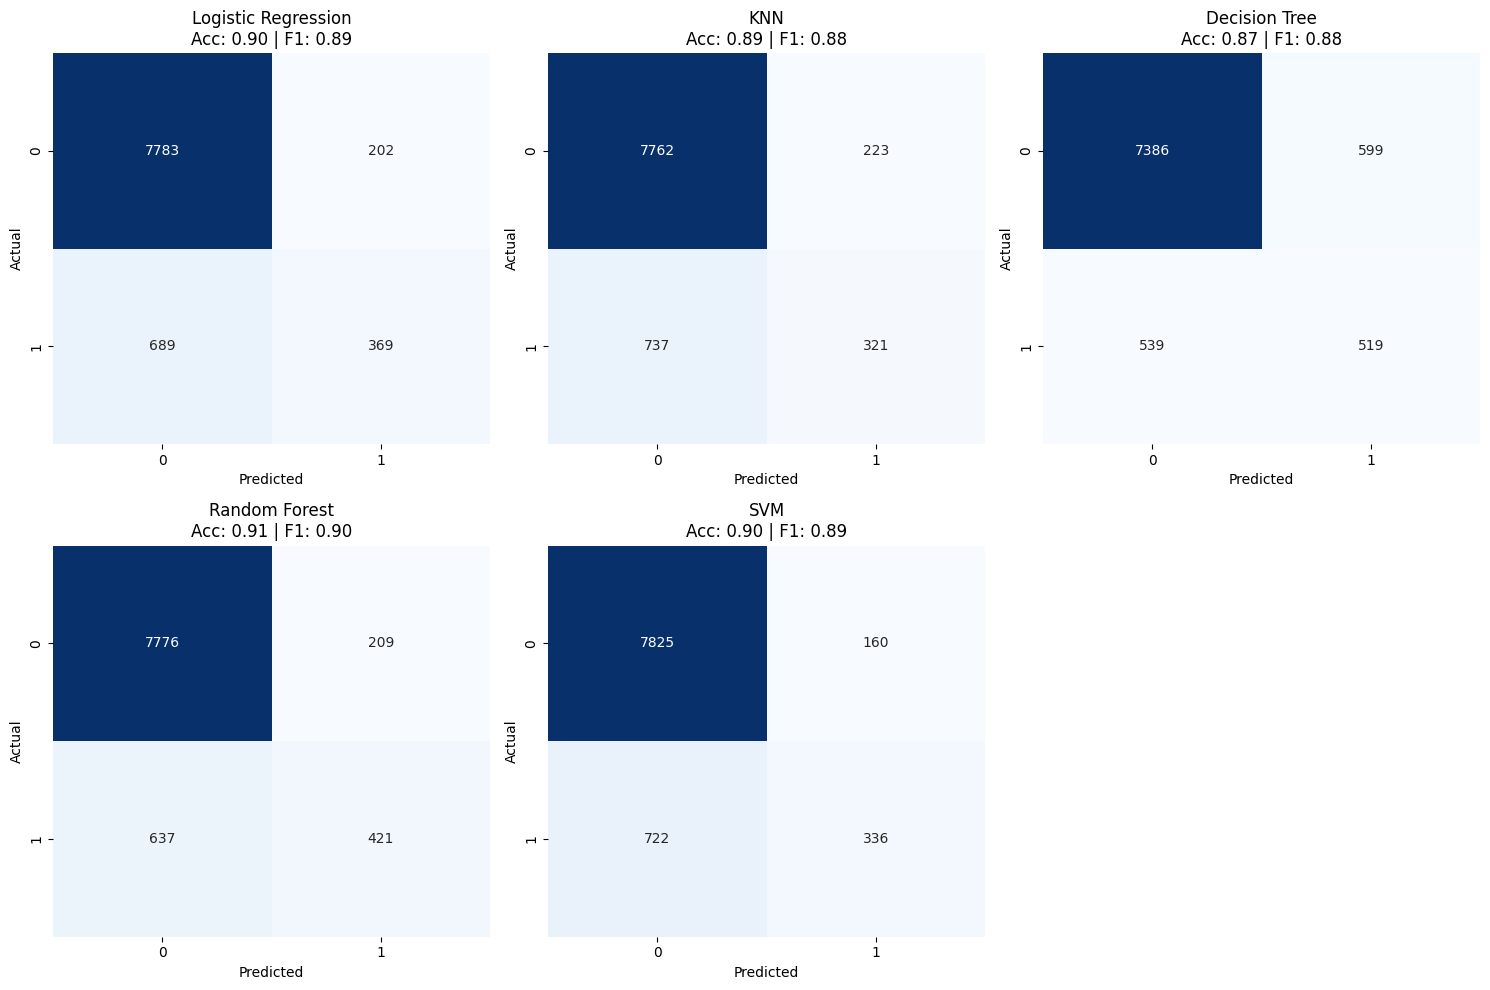

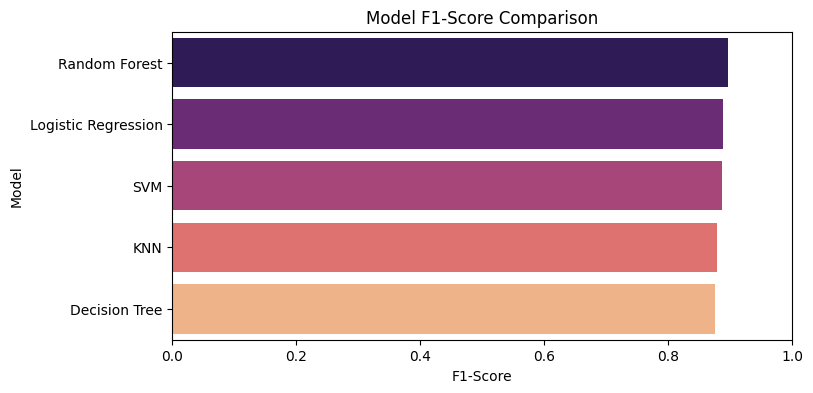


=== MODEL PERFORMANCE RANKING ===
              Model  Accuracy  F1-Score
      Random Forest  0.906447  0.895807
Logistic Regression  0.901471  0.888201
                SVM  0.902466  0.886487
                KNN  0.893841  0.878465
      Decision Tree  0.874157  0.875654


In [8]:
import zipfile
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

# Suppress future warnings for clean notebook output
warnings.simplefilter(action='ignore', category=FutureWarning)

# ==========================================
# 1. EXTRACT & LOAD DATASET
# ==========================================
csv_filename = "bank.csv"

if zipfile.is_zipfile("bank.csv"):
    with zipfile.ZipFile("bank.csv", "r") as z:
        z.extractall(".")
        csv_files = [f for f in z.namelist() if f.endswith(".csv")]
        if csv_files:
            csv_filename = csv_files[0]

df = pd.read_csv(csv_filename, sep=";", encoding="latin1")
if df.shape[1] < 3:
    df = pd.read_csv(csv_filename, sep=",", encoding="latin1")

# Clean column headers
df.columns = df.columns.str.strip().str.replace('"', '').str.replace("'", "")

# Detect target column
possible_targets = ['y', 'response', 'subscribed', 'target']
target_col = next((c for c in possible_targets if c in df.columns), df.columns[-1])

print(f"Dataset shape: {df.shape}")
print(f"Target column detected: '{target_col}'")

# ==========================================
# 2. EXPLORATORY DATA ANALYSIS (WARNING-FREE)
# ==========================================
plt.figure(figsize=(14, 10))

# Graph 1: Target Distribution
plt.subplot(2, 2, 1)
sns.countplot(x=target_col, data=df, hue=target_col, palette="viridis", legend=False)
plt.title(f"Target Distribution ('{target_col}')")

# Graph 2: Age vs Target
plt.subplot(2, 2, 2)
sns.boxplot(x=target_col, y="age", data=df, hue=target_col, palette="Set2", legend=False)
plt.title("Age vs Subscription Outcome")

# Graph 3: Balance vs Target
if "balance" in df.columns:
    plt.subplot(2, 2, 3)
    sns.boxplot(x=target_col, y="balance", data=df, hue=target_col, palette="Set3", legend=False)
    plt.title("Account Balance vs Target")

# Graph 4: Client Job Categories
if "job" in df.columns:
    plt.subplot(2, 2, 4)
    job_order = df['job'].value_counts().index[:8]
    sns.countplot(y="job", data=df, order=job_order, hue="job", palette="mako", legend=False)
    plt.title("Top Client Job Categories")

plt.tight_layout()
plt.show()

# ==========================================
# 3. PREPROCESSING & ENCODING
# ==========================================
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))

# One-hot encode features
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 4. MODEL TRAINING & EVALUATION
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

results = []
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    results.append({"Model": name, "Accuracy": acc, "F1-Score": f1})

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[idx], cbar=False)
    axes[idx].set_title(f"{name}\nAcc: {acc:.2f} | F1: {f1:.2f}")
    axes[idx].set_xlabel("Predicted")
    axes[idx].set_ylabel("Actual")

axes[5].axis("off")
plt.tight_layout()
plt.show()

# ==========================================
# 5. MODEL RANKING CHART
# ==========================================
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x="F1-Score", y="Model", data=results_df, hue="Model", palette="magma", legend=False)
plt.title("Model F1-Score Comparison")
plt.xlim(0, 1)
plt.show()

print("\n=== MODEL PERFORMANCE RANKING ===")
print(results_df.to_string(index=False))